# Imports

In [ ]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

from autogluon.tabular import TabularDataset, TabularPredictor
#from autogluon.multimodal import MultiModalPredictor
import xgboost as xgb

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)

SCORING = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error'
}
GRID_SEARCH_KWARGS = dict(
    cv=10,
    scoring=SCORING,
    refit='r2',
    n_jobs=-1,
    return_train_score=True
)
LINEAR_PARAM_GRID = {
    'model__fit_intercept': [True, False],
    'model__positive': [False, True]
}
TREE_PARAM_GRID = {
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [1, 100],
    'model__min_samples_leaf': [2, 100],
    'model__max_features': [None, 'sqrt', 'log2']
}
RF_PARAM_GRID = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [1, 100],
    'model__min_samples_leaf': [2, 100],
    'model__max_features': [None, 'sqrt', 'log2']
}
MLP_PARAM_GRID = {
    'model__hidden_layer_sizes': [(100,), (100, 50), (50, 25)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.001, 0.01],
    'model__learning_rate_init': [0.001, 0.01]
}
XGB_PARAM_GRID = {
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__n_estimators': [50, 100, 200]
}

def evaluate_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred

    bin_size = 0.1
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=True)

    ece = 0.0
    N = len(y_pred)

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue

        bin_center = (bins[i - 1] + bins[i]) / 2.0
        median_obs = np.median(y_true[mask])
        ece += (mask.sum() / N) * abs(median_obs - bin_center)
        
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': float(np.mean(np.abs(errors))),
        'mse': float(np.mean(errors ** 2)),
        "p95": np.quantile(np.abs(errors), 0.95),
        'ece': float(ece),              # Expected calibration error
    }


def record_regression_results(results, target, model_name, y_true, y_pred, split='test'):
    metrics = evaluate_regression_metrics(y_true, y_pred)
    split_label = split.capitalize()
    print(f"{split_label} R2 score {metrics['r2']:.4f}")
    print(f"{split_label} MAE score {metrics['mae']:.4f}")
    print(f"{split_label} MSE score {metrics['mse']:.4f}")
    print(f"{split_label} P95 score {metrics['p95']:.4f}")
    print(f"{split_label} ECE score {metrics['ece']:.4f}")
    results.append({
        'target': target,
        'model': model_name,
        f'{split}_r2': metrics['r2'],
        f'{split}_mae': metrics['mae'],
        f'{split}_mse': metrics['mse'],
        f'{split}_p95': metrics['p95'],
        f'{split}_ece': metrics['ece'],
    })
    return metrics

def plot_calibration_curve(y_true, y_pred, bin_size=0.1, ax=None, label=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=True)

    avg_predicted = []
    avg_observed = []
    err_low = []
    err_high = []
    rng = np.random.default_rng(0)
    alpha = (1.0 - 0.95) / 2.0    #95% CI

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        avg_predicted.append((bins[i - 1] + bins[i]) / 2)  # Center of bin, so it is not influenced by the data
        avg_observed.append(float(np.median(y_true[mask])))   # Mean of observed IoU

        if 300 > 0: #Bootstrap CI
            boots = np.empty(300)
            n = y_true[mask].size
            for b in range(300):
                boots[b] = np.median(rng.choice(y_true[mask], size=n, replace=True))
            lo = np.quantile(boots, alpha)
            hi = np.quantile(boots, 1.0 - alpha)
            #err_low.append(float(np.median(y_true[mask])) - lo)
            err_low.append(lo)
            #err_high.append(hi - float(np.median(y_true[mask])))
            err_high.append(hi)
        else:
            err_low.append(np.nan)
            err_high.append(np.nan)
    
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect')
    ax.plot(avg_predicted, avg_observed, marker='o', label=label or 'Model')
    ax.fill_between(avg_predicted, err_low, err_high, alpha=0.15)
    #ax.errorbar(avg_predicted,avg_observed,yerr=np.vstack([err_low, err_high]),fmt='o-',capsize=3,label=label or 'Model')
    ax.set_xlabel('Predicted IoU (bin center)')
    ax.set_ylabel('Observed IoU (median)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    if label is not None:
        ax.legend()
    return ax


# Load data

In [105]:
data = pd.read_csv("../data/data_yolo_500e.csv", index_col=0)
print(data)

      country time_of_day        lat       long       road_type  \
8459       SE         day  55.604209  13.028574            city   
63960      DE         day  50.936889   6.908079  arterial-urban   
71801      IT         day  41.987014  12.496538         highway   
85589      IT       night  41.794853  12.522880         highway   
90649      DE         day  49.182153   9.414737         highway   
...       ...         ...        ...        ...             ...   
74962      PL         day  54.378439  18.605984  arterial-urban   
90673      PL         day  50.253217  19.823732   smaller-rural   
24373      DE         day  50.931399   6.953686            city   
41597      SE         day  55.608149  13.003458            city   
40353      IT       night  41.918667  12.383545            city   

      road_condition            weather  solar_angle_elevation  month  hour  \
8459          normal             cloudy              36.560248      5    14   
63960         normal               ra

In [106]:
data = data.dropna().reset_index(drop=True)
num_rows, num_cols = data.shape
print(f"After dropping missing values: {num_rows:,} rows and {num_cols} columns")

After dropping missing values: 10,006 rows and 38 columns


In [107]:
iou = data["iou"]
lrp = data["lrp"]
conf = data["conf"]
image_paths_dict = {int(img_pth.split("_")[0]):f"../data/zod_yolo/images/val/{img_pth}" for img_pth in os.listdir("../data/zod_yolo/images/val") if img_pth.endswith(".jpg")}
img_path = pd.DataFrame.from_dict(image_paths_dict, orient='index', columns=["Images"])

data = data.drop(columns=["iou", "lrp"])
data_indices = data.index.to_numpy()

In [108]:
all_columns = data.columns    
all_columns = all_columns.drop(["weather_code", "cloud_cover_low", "cloud_cover_mid"])

print(f"Number of rows: {data.shape[0]}")
print(f"Columns: {all_columns.sort_values()}")
print(f"Number of columns: {len(all_columns)}")

Number of rows: 10006
Columns: Index(['brightness', 'camera_distance_from_ground', 'camera_offset',
       'camera_pitch_angle', 'cloud_cover', 'complexity', 'conf', 'contrast',
       'country', 'distortion_magnitude', 'field_view_horizontal',
       'forward_acceleration', 'forward_velocity', 'hour', 'laplacian', 'lat',
       'lateral_acceleration', 'lateral_velocity', 'long', 'month',
       'noisiness', 'quality', 'rain', 'relative_humidity_2m',
       'road_condition', 'road_type', 'sharpness', 'snowfall',
       'solar_angle_elevation', 'temperature_2m', 'time_of_day', 'weather',
       'wind_speed_10m'],
      dtype='object')
Number of columns: 33


In [109]:
numeric_columns = ['conf', 'solar_angle_elevation', 'temperature_2m', 'relative_humidity_2m', 'rain', 'snowfall', 'cloud_cover', 'wind_speed_10m', 'forward_acceleration', 'lateral_acceleration', 'forward_velocity', 'lateral_velocity', 'field_view_horizontal', 'camera_distance_from_ground', 'camera_pitch_angle', 'distortion_magnitude', 'camera_offset', 'laplacian', 'brightness', 'contrast', 'sharpness', 'noisiness', 'quality', 'complexity']

categorical_columns = ["country", "time_of_day", "road_type", "road_condition", "weather"]
other = ["hour", "month", "lat", "long"]
print(sorted(numeric_columns + categorical_columns + other))
assert len(all_columns) == (len(categorical_columns) + len(numeric_columns) + len(other)), "Columns not match"

['brightness', 'camera_distance_from_ground', 'camera_offset', 'camera_pitch_angle', 'cloud_cover', 'complexity', 'conf', 'contrast', 'country', 'distortion_magnitude', 'field_view_horizontal', 'forward_acceleration', 'forward_velocity', 'hour', 'laplacian', 'lat', 'lateral_acceleration', 'lateral_velocity', 'long', 'month', 'noisiness', 'quality', 'rain', 'relative_humidity_2m', 'road_condition', 'road_type', 'sharpness', 'snowfall', 'solar_angle_elevation', 'temperature_2m', 'time_of_day', 'weather', 'wind_speed_10m']


# Assessor Tests

Split data into train 60% and validation 40%

In [110]:
#X_train, X_test, y_train, y_test = train_test_split(data, test_size=0.4, train_size=0.6, stratify=data["iou"])
train_idx, test_idx = train_test_split(data_indices, test_size=0.4, train_size=0.6)

X_train = data.loc[train_idx]
y_train = iou.loc[train_idx]
y_train_lrp = lrp.loc[train_idx]
conf_train = conf.loc[train_idx]
conf_train = pd.DataFrame(conf_train)

X_test = data.loc[test_idx]
y_test = iou.loc[test_idx]
y_test_lrp = lrp.loc[test_idx]
conf_test = conf.loc[test_idx]
conf_test = pd.DataFrame(conf_test)

print("X:", len(X_train), len(X_test))
print("y:", len(y_train), len(y_test))
print("Conf:", len(conf_train), len(conf_test))
print(X_train.columns)

X: 6003 4003
y: 6003 4003
Conf: 6003 4003
Index(['country', 'time_of_day', 'lat', 'long', 'road_type', 'road_condition',
       'weather', 'solar_angle_elevation', 'month', 'hour',
       'forward_acceleration', 'lateral_acceleration', 'forward_velocity',
       'lateral_velocity', 'field_view_horizontal',
       'camera_distance_from_ground', 'camera_pitch_angle',
       'distortion_magnitude', 'camera_offset', 'laplacian', 'quality',
       'brightness', 'noisiness', 'sharpness', 'contrast', 'complexity',
       'temperature_2m', 'relative_humidity_2m', 'rain', 'snowfall',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'wind_speed_10m',
       'weather_code', 'conf'],
      dtype='object')


In [111]:
model_results = []

### IoU

#### Baseline

Random Prediction. Mean of metric over training set.

In [112]:
mean_iou_train = np.mean(y_train)
iou_pred_test = np.full_like(y_test, mean_iou_train)
record_regression_results(model_results, 'IoU', 'Constant Mean Predictor', y_test, iou_pred_test)


Test R2 score -0.0004
Test MAE score 0.1227
Test MSE score 0.0273
Test P95 score 0.4198
Test ECE score 0.0316


{'r2': -0.000411697943840883,
 'mae': 0.12270265982839079,
 'mse': 0.02726715275943323,
 'p95': 0.41982657570619675,
 'ece': 0.031551094020583814}

#### Linear Reg on Conf

In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['conf']),
    ],
    remainder='passthrough'
)
linear_reg_conf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear_reg_conf_grid = GridSearchCV(
    linear_reg_conf_pipeline,
    param_grid=LINEAR_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
linear_reg_conf_grid.fit(conf_train, y_train)

best_idx = linear_reg_conf_grid.best_index_
mean_train_r2 = linear_reg_conf_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = linear_reg_conf_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -linear_reg_conf_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -linear_reg_conf_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -linear_reg_conf_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -linear_reg_conf_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {linear_reg_conf_grid.best_params_}")
best_linear_reg_conf = linear_reg_conf_grid.best_estimator_


Mean CV train r2 score 0.3408
Mean CV test r2 score 0.3394
Mean CV train MAE score 0.1014
Mean CV test MAE score 0.1015
Mean CV train MSE score 0.0181
Mean CV test MSE score 0.0181
Best params: {'model__fit_intercept': True, 'model__positive': False}


In [114]:
y_pred_iou_baseline = best_linear_reg_conf.predict(conf_test)
record_regression_results(model_results, 'IoU', 'Univariate Linear Regression (Confidence)', y_test, y_pred_iou_baseline)


Test R2 score 0.3493
Test MAE score 0.0996
Test MSE score 0.0177
Test P95 score 0.2888
Test ECE score 0.0137


{'r2': 0.3492755632926138,
 'mae': 0.09959272713173703,
 'mse': 0.01773610070380493,
 'p95': 0.28880199925254546,
 'ece': 0.013744804316246842}

#### Linear Regression

Train models with cv and then test.

In [115]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
linear_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear_reg_grid = GridSearchCV(
    linear_reg_pipeline,
    param_grid=LINEAR_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
linear_reg_grid.fit(X_train, y_train)

best_idx = linear_reg_grid.best_index_
mean_train_r2 = linear_reg_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = linear_reg_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -linear_reg_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -linear_reg_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -linear_reg_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -linear_reg_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {linear_reg_grid.best_params_}")
best_linear_reg = linear_reg_grid.best_estimator_

Mean CV train r2 score 0.3753
Mean CV test r2 score 0.3556
Mean CV train MAE score 0.0992
Mean CV test MAE score 0.1005
Mean CV train MSE score 0.0172
Mean CV test MSE score 0.0177
Best params: {'model__fit_intercept': True, 'model__positive': False}


In [116]:
y_pred_iou_lr = best_linear_reg.predict(X_test)
record_regression_results(model_results, 'IoU', 'Linear Regression', y_test, y_pred_iou_lr)


Test R2 score 0.3679
Test MAE score 0.0984
Test MSE score 0.0172
Test P95 score 0.2755
Test ECE score 0.0154


{'r2': 0.36787475704167627,
 'mae': 0.09839749056707119,
 'mse': 0.01722916235212399,
 'p95': 0.2755186850374606,
 'ece': 0.015391431868386651}

#### Decision Trees

In [117]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=SEED))
])
decision_tree_grid = GridSearchCV(
    decision_tree_pipeline,
    param_grid=TREE_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
decision_tree_grid.fit(X_train, y_train)

best_idx = decision_tree_grid.best_index_
mean_train_r2 = decision_tree_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = decision_tree_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -decision_tree_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -decision_tree_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -decision_tree_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -decision_tree_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {decision_tree_grid.best_params_}")
best_decision_tree = decision_tree_grid.best_estimator_


Mean CV train r2 score 0.4001
Mean CV test r2 score 0.3323
Mean CV train MAE score 0.0962
Mean CV test MAE score 0.1015
Mean CV train MSE score 0.0165
Mean CV test MSE score 0.0184
Best params: {'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 100, 'model__min_samples_split': 100}


/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *ar

In [118]:
y_pred_iou_dt = best_decision_tree.predict(X_test)
record_regression_results(model_results, 'IoU', 'Decision Tree', y_test, y_pred_iou_dt)


Test R2 score 0.3425
Test MAE score 0.0997
Test MSE score 0.0179
Test P95 score 0.2787
Test ECE score 0.0125


{'r2': 0.34247582826408673,
 'mae': 0.09966105633486737,
 'mse': 0.01792143381629011,
 'p95': 0.2786963522625718,
 'ece': 0.012526721930462156}

#### Random Forest

In [119]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
rand_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])
rand_forest_grid = GridSearchCV(
    rand_forest_pipeline,
    param_grid=RF_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
rand_forest_grid.fit(X_train, y_train)

best_idx = rand_forest_grid.best_index_
mean_train_r2 = rand_forest_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = rand_forest_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -rand_forest_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -rand_forest_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -rand_forest_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -rand_forest_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {rand_forest_grid.best_params_}")
best_rand_forest = rand_forest_grid.best_estimator_


/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
360 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *ar

Mean CV train r2 score 0.4843
Mean CV test r2 score 0.3627
Mean CV train MAE score 0.0900
Mean CV test MAE score 0.0990
Mean CV train MSE score 0.0142
Mean CV test MSE score 0.0175
Best params: {'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 100, 'model__n_estimators': 200}


In [120]:
y_pred_iou_rf = best_rand_forest.predict(X_test)
record_regression_results(model_results, 'IoU', 'Random Forest', y_test, y_pred_iou_rf)


Test R2 score 0.3772
Test MAE score 0.0969
Test MSE score 0.0170
Test P95 score 0.2688
Test ECE score 0.0068


{'r2': 0.3771662820774947,
 'mae': 0.09688878235641954,
 'mse': 0.016975913181766944,
 'p95': 0.2687518047027401,
 'ece': 0.006781018511238544}

#### MLP

In [121]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(max_iter=500, random_state=SEED))
])
mlp_grid = GridSearchCV(
    mlp_pipeline,
    param_grid=MLP_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
mlp_grid.fit(X_train, y_train)

best_idx = mlp_grid.best_index_
mean_train_r2 = mlp_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = mlp_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -mlp_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -mlp_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -mlp_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -mlp_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {mlp_grid.best_params_}")
best_mlp = mlp_grid.best_estimator_


Mean CV train r2 score 0.3790
Mean CV test r2 score 0.2738
Mean CV train MAE score 0.0999
Mean CV test MAE score 0.1069
Mean CV train MSE score 0.0171
Mean CV test MSE score 0.0199
Best params: {'model__activation': 'tanh', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (50, 25), 'model__learning_rate_init': 0.001}


In [122]:
y_pred_iou_mlp = best_mlp.predict(X_test)
record_regression_results(model_results, 'IoU', 'MLP', y_test, y_pred_iou_mlp)


Test R2 score 0.3279
Test MAE score 0.1023
Test MSE score 0.0183
Test P95 score 0.2816
Test ECE score 0.0178


{'r2': 0.3279143964013944,
 'mae': 0.10225266870592063,
 'mse': 0.018318319206387174,
 'p95': 0.2816017513794091,
 'ece': 0.017785539048655347}

#### XGBoost

In [123]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor())
])
xgb_grid = GridSearchCV(
    xgb_pipeline,
    param_grid=XGB_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
xgb_grid.fit(X_train, y_train)


best_idx = xgb_grid.best_index_
mean_train_r2 = xgb_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = xgb_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -xgb_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -xgb_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -xgb_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -xgb_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {xgb_grid.best_params_}")
best_xgb = xgb_grid.best_estimator_

Mean CV train r2 score 0.5142
Mean CV test r2 score 0.3464
Mean CV train MAE score 0.0898
Mean CV test MAE score 0.1014
Mean CV train MSE score 0.0134
Mean CV test MSE score 0.0179
Best params: {'model__learning_rate': 0.01, 'model__n_estimators': 200}


In [124]:
y_pred_iou_xgb = best_xgb.predict(X_test)
record_regression_results(model_results, 'IoU', 'XGBoost', y_test, y_pred_iou_xgb)


Test R2 score 0.3618
Test MAE score 0.0997
Test MSE score 0.0174
Test P95 score 0.2764
Test ECE score 0.0074


{'r2': 0.3618486495444264,
 'mae': 0.09970417027234328,
 'mse': 0.017393409525572674,
 'p95': 0.2764471489191052,
 'ece': 0.007396555600321538}

#### Autogluon

##### Tabluar

In [125]:
train = pd.merge(X_train, y_train, left_index=True, right_index=True)

In [126]:
autoglue_model = TabularPredictor(label="iou", problem_type="regression", eval_metric="r2", path="../models/assessors/autoglue_tab/iou/")
autoglue_predictor = autoglue_model.fit(train)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Debian 6.12.41-1 (2025-08-12)
CPU Count:          32
Pytorch Version:    2.7.1+cu126
CUDA Version:       12.6
GPU Memory:         GPU 0: 23.56/23.56 GB
Total GPU Memory:   Free: 23.56 GB, Allocated: 0.00 GB, Total: 23.56 GB
GPU Count:          1
Memory Avail:       8.75 GB / 30.47 GB (28.7%)
Disk Space Avail:   1445.15 GB / 3542.28 GB (40.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular 

In [127]:
autoglue_predictor.fit_summary(verbosity=2)

*** Summary of fit() ***
Estimated performance of each model:
                 model  score_val eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L2   0.377912          r2       0.017987  3.802360                0.000235           0.021496            2       True         10
1             CatBoost   0.371956          r2       0.002084  1.201817                0.002084           1.201817            1       True          4
2              XGBoost   0.371115          r2       0.008804  0.354258                0.008804           0.354258            1       True          7
3             LightGBM   0.361793          r2       0.001060  0.458020                0.001060           0.458020            1       True          2
4        LightGBMLarge   0.355660          r2       0.001688  1.477910                0.001688           1.477910            1       True          9
5           LightGBMXT   0.354881          r

/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/autogluon/core/utils/plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


{'model_types': {'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestMSE': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesMSE': 'XTModel',
  'NeuralNetFastAI': 'NNFastAiTabularModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT': 0.3548807034755592,
  'LightGBM': 0.3617932866542023,
  'RandomForestMSE': 0.3545027243775368,
  'CatBoost': 0.37195591135028083,
  'ExtraTreesMSE': 0.3530946236191813,
  'NeuralNetFastAI': 0.32565862852932714,
  'XGBoost': 0.3711150623557782,
  'NeuralNetTorch': 0.35077658613760554,
  'LightGBMLarge': 0.3556595511810794,
  'WeightedEnsemble_L2': 0.3779118529266047},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT': ['LightGBMXT'],
  'LightGBM': ['LightGBM'],
  'RandomForestMSE': ['RandomForestMSE'],
  'CatBoost': ['CatBoost'],
  'ExtraTreesMSE': ['ExtraTreesMSE'],
  'N

In [128]:
y_pred_iou_autg = autoglue_predictor.predict(X_test)
record_regression_results(model_results, 'IoU', 'Autogluon_Tab', y_test, y_pred_iou_autg)


Test R2 score 0.3862
Test MAE score 0.0970
Test MSE score 0.0167
Test P95 score 0.2681
Test ECE score 0.0098


{'r2': 0.3861600605717975,
 'mae': 0.09702471673399514,
 'mse': 0.01673077937076424,
 'p95': 0.2681151157617569,
 'ece': 0.009834677425013687}

##### Images

In [129]:
X_train_img = pd.merge(X_train, img_path, left_index=True, right_index=True)
X_test_img = pd.merge(X_test, img_path, how="left", right_index=True, left_index=True)
train_img = pd.merge(X_train_img, y_train, left_index=True, right_index=True)

In [130]:
#autoglue_model_img = MultiModalPredictor(label="iou", problem_type="regression", eval_metric="r2", path="../models/assessors/autoglue_tab/iou/img/")
hyperparams = {
    "env.strategy": "ddp_notebook",
    "env.num_gpus": 1,
    "env.num_workers": 0,
    #"optim.max_epochs": 15,
    #"optim.patience": 3,
    #"optim.learning_rate": 1e-4,
    #"optim.weight_decay": 1e-4,
    #"optim.warmup_steps": 500,
    #"env.per_gpu_batch_size": 8,
    #"env.batch_size": 128,
    #"model.timm_image.checkpoint_name": "convnext_base",
}
#autoglue_predictor_img = autoglue_model_img.fit(train_img, hyperparameters=hyperparams)

In [131]:
#autoglue_predictor_img.fit_summary(verbosity=2)

In [132]:
#y_pred = autoglue_predictor_img.predict(X_test_img)
#record_regression_results(model_results, 'IoU', 'Autogluon_Mult', y_test, y_pred)


### LRP


#### Baseline

Predict Only the Mean


In [133]:
mean_lrp_train = np.mean(y_train_lrp)
lrp_pred_test = np.full_like(y_test_lrp, mean_lrp_train)
record_regression_results(model_results, 'LRP', 'Constant Mean Predictor', y_test_lrp, lrp_pred_test)


Test R2 score -0.0002
Test MAE score 0.1054
Test MSE score 0.0206
Test P95 score 0.2931
Test ECE score 0.0313


{'r2': -0.00020212641402572729,
 'mae': 0.10535191902178924,
 'mse': 0.020621686682595643,
 'p95': 0.2931295994612727,
 'ece': 0.03130990266799921}

#### Linear Reg on Conf

In [134]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['conf']),
    ],
    remainder='passthrough'
)
linear_reg_conf_lrp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear_reg_conf_lrp_grid = GridSearchCV(
    linear_reg_conf_lrp_pipeline,
    param_grid=LINEAR_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
linear_reg_conf_lrp_grid.fit(conf_train, y_train_lrp)

best_idx = linear_reg_conf_lrp_grid.best_index_
mean_train_r2 = linear_reg_conf_lrp_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = linear_reg_conf_lrp_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -linear_reg_conf_lrp_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -linear_reg_conf_lrp_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -linear_reg_conf_lrp_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -linear_reg_conf_lrp_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {linear_reg_conf_lrp_grid.best_params_}")
best_linear_reg_conf_lrp = linear_reg_conf_lrp_grid.best_estimator_


Mean CV train r2 score 0.3990
Mean CV test r2 score 0.3975
Mean CV train MAE score 0.0827
Mean CV test MAE score 0.0827
Mean CV train MSE score 0.0126
Mean CV test MSE score 0.0127
Best params: {'model__fit_intercept': True, 'model__positive': False}


In [135]:
y_pred_lrp_baseline = best_linear_reg_conf_lrp.predict(conf_test)
record_regression_results(model_results, 'LRP', 'Univariate Linear Regression (Confidence)', y_test_lrp, y_pred_lrp_baseline)


Test R2 score 0.3946
Test MAE score 0.0822
Test MSE score 0.0125
Test P95 score 0.2314
Test ECE score 0.0100


{'r2': 0.39461935710525986,
 'mae': 0.08219698151618399,
 'mse': 0.012481447111337186,
 'p95': 0.23137889280116977,
 'ece': 0.01000964078729288}

#### Linear Regression


Train models with cv and then test.


In [136]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
linear_reg_lrp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear_reg_lrp_grid = GridSearchCV(
    linear_reg_lrp_pipeline,
    param_grid=LINEAR_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
linear_reg_lrp_grid.fit(X_train, y_train_lrp)

best_idx = linear_reg_lrp_grid.best_index_
mean_train_r2 = linear_reg_lrp_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = linear_reg_lrp_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -linear_reg_lrp_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -linear_reg_lrp_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -linear_reg_lrp_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -linear_reg_lrp_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {linear_reg_lrp_grid.best_params_}")
best_linear_reg_lrp = linear_reg_lrp_grid.best_estimator_


Mean CV train r2 score 0.4405
Mean CV test r2 score 0.4199
Mean CV train MAE score 0.0796
Mean CV test MAE score 0.0808
Mean CV train MSE score 0.0118
Mean CV test MSE score 0.0122
Best params: {'model__fit_intercept': False, 'model__positive': False}


In [137]:
y_pred_lrp_lr = best_linear_reg_lrp.predict(X_test)
record_regression_results(model_results, 'LRP', 'Linear Regression', y_test_lrp, y_pred_lrp_lr)


Test R2 score 0.4208
Test MAE score 0.0802
Test MSE score 0.0119
Test P95 score 0.2303
Test ECE score 0.0077


{'r2': 0.4207603774928569,
 'mae': 0.08015945218330568,
 'mse': 0.01194248411799795,
 'p95': 0.2303178235456461,
 'ece': 0.007703348767182666}

#### Decision Trees


In [138]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
decision_tree_lrp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=SEED))
])
decision_tree_lrp_grid = GridSearchCV(
    decision_tree_lrp_pipeline,
    param_grid=TREE_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
decision_tree_lrp_grid.fit(X_train, y_train_lrp)

best_idx = decision_tree_lrp_grid.best_index_
mean_train_r2 = decision_tree_lrp_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = decision_tree_lrp_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -decision_tree_lrp_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -decision_tree_lrp_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -decision_tree_lrp_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -decision_tree_lrp_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {decision_tree_lrp_grid.best_params_}")
best_decision_tree_lrp = decision_tree_lrp_grid.best_estimator_


Mean CV train r2 score 0.4632
Mean CV test r2 score 0.4041
Mean CV train MAE score 0.0764
Mean CV test MAE score 0.0802
Mean CV train MSE score 0.0113
Mean CV test MSE score 0.0125
Best params: {'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 100, 'model__min_samples_split': 100}


/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *ar

In [139]:
y_pred_lrp_dt = best_decision_tree_lrp.predict(X_test)
record_regression_results(model_results, 'LRP', 'Decision Tree', y_test_lrp, y_pred_lrp_dt)


Test R2 score 0.4108
Test MAE score 0.0785
Test MSE score 0.0121
Test P95 score 0.2294
Test ECE score 0.0153


{'r2': 0.4107525647435456,
 'mae': 0.0784986856395214,
 'mse': 0.012148820390881412,
 'p95': 0.22943935165745868,
 'ece': 0.015306365384240744}

#### Random Forest


In [140]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
rand_forest_lrp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])
rand_forest_lrp_grid = GridSearchCV(
    rand_forest_lrp_pipeline,
    param_grid=RF_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
rand_forest_lrp_grid.fit(X_train, y_train_lrp)

best_idx = rand_forest_lrp_grid.best_index_
mean_train_r2 = rand_forest_lrp_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = rand_forest_lrp_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -rand_forest_lrp_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -rand_forest_lrp_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -rand_forest_lrp_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -rand_forest_lrp_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {rand_forest_lrp_grid.best_params_}")
best_rand_forest_lrp = rand_forest_lrp_grid.best_estimator_


/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
360 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *ar

Mean CV train r2 score 0.5521
Mean CV test r2 score 0.4354
Mean CV train MAE score 0.0704
Mean CV test MAE score 0.0780
Mean CV train MSE score 0.0094
Mean CV test MSE score 0.0118
Best params: {'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 100, 'model__n_estimators': 200}


In [141]:
y_pred_lrp_rf = best_rand_forest_lrp.predict(X_test)
record_regression_results(model_results, 'LRP', 'Random Forest', y_test_lrp, y_pred_lrp_rf)


Test R2 score 0.4329
Test MAE score 0.0772
Test MSE score 0.0117
Test P95 score 0.2295
Test ECE score 0.0104


{'r2': 0.43291491495384016,
 'mae': 0.077166503173072,
 'mse': 0.011691887706859631,
 'p95': 0.2295271002023338,
 'ece': 0.010422035711513842}

#### MLP


In [142]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
mlp_lrp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(max_iter=500, random_state=SEED))
])
mlp_lrp_grid = GridSearchCV(
    mlp_lrp_pipeline,
    param_grid=MLP_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
mlp_lrp_grid.fit(X_train, y_train_lrp)

best_idx = mlp_lrp_grid.best_index_
mean_train_r2 = mlp_lrp_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = mlp_lrp_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -mlp_lrp_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -mlp_lrp_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -mlp_lrp_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -mlp_lrp_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {mlp_lrp_grid.best_params_}")
best_mlp_lrp = mlp_lrp_grid.best_estimator_


Mean CV train r2 score 0.3630
Mean CV test r2 score 0.3370
Mean CV train MAE score 0.0857
Mean CV test MAE score 0.0870
Mean CV train MSE score 0.0134
Mean CV test MSE score 0.0139
Best params: {'model__activation': 'relu', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (50, 25), 'model__learning_rate_init': 0.01}


In [143]:
y_pred_lrp_mlp = best_mlp_lrp.predict(X_test)
record_regression_results(model_results, 'LRP', 'MLP', y_test_lrp, y_pred_lrp_mlp)


Test R2 score 0.4052
Test MAE score 0.0805
Test MSE score 0.0123
Test P95 score 0.2348
Test ECE score 0.0138


{'r2': 0.405182536682688,
 'mae': 0.08051853813523645,
 'mse': 0.012263660552135703,
 'p95': 0.23481937110704354,
 'ece': 0.013816063430289646}

#### XGBoost

In [144]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)
xgb_lrp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor())
])
xgb_lrp_grid = GridSearchCV(
    xgb_lrp_pipeline,
    param_grid=XGB_PARAM_GRID,
    **GRID_SEARCH_KWARGS
)
xgb_lrp_grid.fit(X_train, y_train_lrp)


best_idx = xgb_lrp_grid.best_index_
mean_train_r2 = xgb_lrp_grid.cv_results_['mean_train_r2'][best_idx]
mean_test_r2 = xgb_lrp_grid.cv_results_['mean_test_r2'][best_idx]
mean_train_mae = -xgb_lrp_grid.cv_results_['mean_train_mae'][best_idx]
mean_test_mae = -xgb_lrp_grid.cv_results_['mean_test_mae'][best_idx]
mean_train_mse = -xgb_lrp_grid.cv_results_['mean_train_mse'][best_idx]
mean_test_mse = -xgb_lrp_grid.cv_results_['mean_test_mse'][best_idx]
print(f"Mean CV train r2 score {mean_train_r2:.4f}")
print(f"Mean CV test r2 score {mean_test_r2:.4f}")
print(f"Mean CV train MAE score {mean_train_mae:.4f}")
print(f"Mean CV test MAE score {mean_test_mae:.4f}")
print(f"Mean CV train MSE score {mean_train_mse:.4f}")
print(f"Mean CV test MSE score {mean_test_mse:.4f}")
print(f"Best params: {xgb_lrp_grid.best_params_}")
best_xgb_lrp = xgb_lrp_grid.best_estimator_

Mean CV train r2 score 0.6028
Mean CV test r2 score 0.4192
Mean CV train MAE score 0.0693
Mean CV test MAE score 0.0797
Mean CV train MSE score 0.0084
Mean CV test MSE score 0.0122
Best params: {'model__learning_rate': 0.01, 'model__n_estimators': 200}


In [145]:
y_pred_lrp_xgb = best_xgb_lrp.predict(X_test)
record_regression_results(model_results, 'LRP', 'XGBoost', y_test_lrp, y_pred_lrp_xgb)


Test R2 score 0.4130
Test MAE score 0.0794
Test MSE score 0.0121
Test P95 score 0.2284
Test ECE score 0.0077


{'r2': 0.4129734800166993,
 'mae': 0.0794298709250378,
 'mse': 0.012103030627290559,
 'p95': 0.2283972471952438,
 'ece': 0.007687669145206272}

#### Autogluon

##### Tabluar

In [146]:
train_lrp = pd.merge(X_train, y_train_lrp, left_index=True, right_index=True)

In [147]:
autoglue_model_lrp = TabularPredictor(label="lrp", problem_type="regression", eval_metric="r2", path="../models/assessors/autoglue_tab/lrp/tab/")
autoglue_predictor_lrp = autoglue_model_lrp.fit(train_lrp)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Debian 6.12.41-1 (2025-08-12)
CPU Count:          32
Pytorch Version:    2.7.1+cu126
CUDA Version:       12.6
GPU Memory:         GPU 0: 23.56/23.56 GB
Total GPU Memory:   Free: 23.56 GB, Allocated: 0.00 GB, Total: 23.56 GB
GPU Count:          1
Memory Avail:       8.52 GB / 30.47 GB (28.0%)
Disk Space Avail:   1445.15 GB / 3542.28 GB (40.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular 

In [148]:
autoglue_predictor_lrp.fit_summary(verbosity=2)

*** Summary of fit() ***
Estimated performance of each model:
                 model  score_val eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L2   0.459325          r2       0.011048  8.901003                0.000235           0.023183            2       True         10
1             CatBoost   0.439702          r2       0.002281  1.456177                0.002281           1.456177            1       True          4
2           LightGBMXT   0.437989          r2       0.001681  0.620067                0.001681           0.620067            1       True          1
3       NeuralNetTorch   0.436399          r2       0.006850  6.801575                0.006850           6.801575            1       True          8
4             LightGBM   0.428459          r2       0.001358  0.476083                0.001358           0.476083            1       True          2
5      RandomForestMSE   0.419664          r

/home/felix/.cache/pypoetry/virtualenvs/predictability-ad-NSMX3dx--py3.11/lib/python3.11/site-packages/autogluon/core/utils/plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


{'model_types': {'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestMSE': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesMSE': 'XTModel',
  'NeuralNetFastAI': 'NNFastAiTabularModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT': 0.4379893392889389,
  'LightGBM': 0.4284585965185018,
  'RandomForestMSE': 0.41966368180492186,
  'CatBoost': 0.439702264460187,
  'ExtraTreesMSE': 0.4155029354075469,
  'NeuralNetFastAI': 0.38280439842584624,
  'XGBoost': 0.41270335853995377,
  'NeuralNetTorch': 0.43639888867503573,
  'LightGBMLarge': 0.4040548706159537,
  'WeightedEnsemble_L2': 0.45932458908951934},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT': ['LightGBMXT'],
  'LightGBM': ['LightGBM'],
  'RandomForestMSE': ['RandomForestMSE'],
  'CatBoost': ['CatBoost'],
  'ExtraTreesMSE': ['ExtraTreesMSE'],
  '

In [149]:
y_pred_lrp_autg = autoglue_predictor_lrp.predict(X_test)
record_regression_results(model_results, 'LRP', 'Autogluon_Tab', y_test_lrp, y_pred_lrp_autg)


Test R2 score 0.4322
Test MAE score 0.0774
Test MSE score 0.0117
Test P95 score 0.2290
Test ECE score 0.0131


{'r2': 0.4321836058520244,
 'mae': 0.07738329538011063,
 'mse': 0.011706965486407895,
 'p95': 0.22902427017688734,
 'ece': 0.013138559418203478}

##### Images

In [150]:
X_train_img = pd.merge(X_train, img_path, left_index=True, right_index=True)
X_test_img = pd.merge(X_test, img_path, how="left", right_index=True, left_index=True)
train_lrp_img = pd.merge(X_train_img, y_train_lrp, left_index=True, right_index=True)

In [151]:
#autoglue_model_lrp_img = MultiModalPredictor(label="lrp", problem_type="regression", eval_metric="r2", path="../models/assessors/autoglue_tab/lrp/img/")
hyperparams = {
    "env.strategy": "ddp_notebook",
    "env.num_gpus": 1,
    "env.num_workers": 0,
    #"optim.max_epochs": 15,
    #"optim.patience": 3,
    #"optim.learning_rate": 1e-4,
    #"optim.weight_decay": 1e-4,
    #"optim.warmup_steps": 500,
    #"env.per_gpu_batch_size": 8,
    #"env.batch_size": 128,
    #"model.timm_image.checkpoint_name": "convnext_base",
}
#autoglue_predictor_lrp_img = autoglue_model_lrp_img.fit(train_lrp_img, hyperparameters=hyperparams)

In [152]:
#autoglue_predictor_lrp_img.fit_summary(verbosity=2)

In [153]:
#y_pred = autoglue_predictor_lrp_img.predict(X_test_img)
#record_regression_results(model_results, 'LRP', 'Autogluon_Mult', y_test_lrp, y_pred)


### Final Model Comparison


In [154]:
results_df = pd.DataFrame(model_results, index=None)
results_df["test_r2"] = results_df["test_r2"].round(4)
results_df["test_mae"] = results_df["test_mae"].round(4)
results_df["test_mse"] = results_df["test_mse"].round(4)
results_df.to_csv("results.csv")
display(results_df)


,target,model,test_r2,test_mae,test_mse,test_p95,test_ece
0,IoU,Constant Mean Predictor,-0.0004,0.1227,0.0273,0.419827,0.031551
1,IoU,Univariate Linear Regression (Confidence),0.3493,0.0996,0.0177,0.288802,0.013745
2,IoU,Linear Regression,0.3679,0.0984,0.0172,0.275519,0.015391
3,IoU,Decision Tree,0.3425,0.0997,0.0179,0.278696,0.012527
4,IoU,Random Forest,0.3772,0.0969,0.0170,0.268752,0.006781
5,IoU,MLP,0.3279,0.1023,0.0183,0.281602,0.017786
6,IoU,XGBoost,0.3618,0.0997,0.0174,0.276447,0.007397
7,IoU,Autogluon_Tab,0.3862,0.0970,0.0167,0.268115,0.009835
8,LRP,Constant Mean Predictor,-0.0002,0.1054,0.0206,0.293130,0.031310
9,LRP,Univariate Linear Regression (Confidence),0.3946,0.0822,0.0125,0.231379,0.010010


In [155]:
print(results_df.to_latex(index=False))

\begin{tabular}{llrrrrr}
\toprule
target & model & test_r2 & test_mae & test_mse & test_p95 & test_ece \\
\midrule
IoU & Constant Mean Predictor & -0.000400 & 0.122700 & 0.027300 & 0.419827 & 0.031551 \\
IoU & Univariate Linear Regression (Confidence) & 0.349300 & 0.099600 & 0.017700 & 0.288802 & 0.013745 \\
IoU & Linear Regression & 0.367900 & 0.098400 & 0.017200 & 0.275519 & 0.015391 \\
IoU & Decision Tree & 0.342500 & 0.099700 & 0.017900 & 0.278696 & 0.012527 \\
IoU & Random Forest & 0.377200 & 0.096900 & 0.017000 & 0.268752 & 0.006781 \\
IoU & MLP & 0.327900 & 0.102300 & 0.018300 & 0.281602 & 0.017786 \\
IoU & XGBoost & 0.361800 & 0.099700 & 0.017400 & 0.276447 & 0.007397 \\
IoU & Autogluon_Tab & 0.386200 & 0.097000 & 0.016700 & 0.268115 & 0.009835 \\
LRP & Constant Mean Predictor & -0.000200 & 0.105400 & 0.020600 & 0.293130 & 0.031310 \\
LRP & Univariate Linear Regression (Confidence) & 0.394600 & 0.082200 & 0.012500 & 0.231379 & 0.010010 \\
LRP & Linear Regression & 0.420800 & 0.

# Regression Reliability Plots

IoU

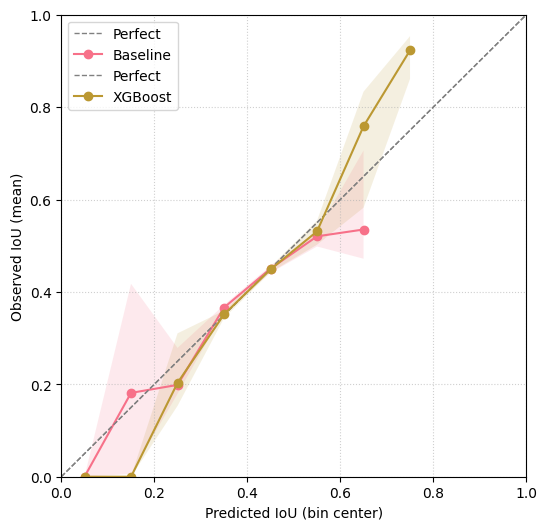

In [160]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_calibration_curve(y_test, y_pred_iou_baseline, ax=ax, label="Baseline")
#plot_calibration_curve(y_test, y_pred_iou_xgb, ax=ax, label="XGBoost")
plot_calibration_curve(y_test, y_pred_iou_xgb, ax=ax, label="XGBoost")
ax.legend()

LRP

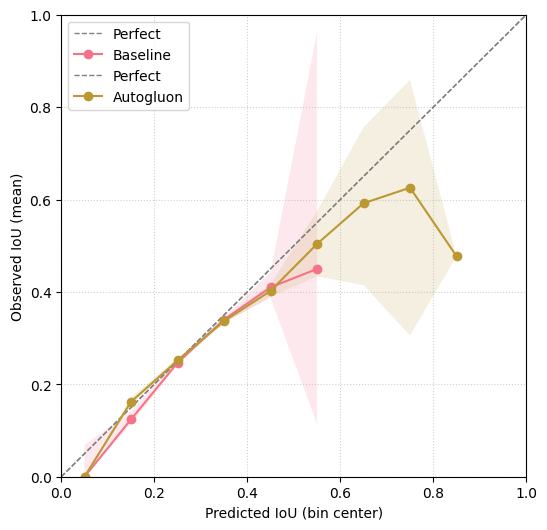

In [162]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_calibration_curve(y_test_lrp, y_pred_lrp_baseline, ax=ax, label="Baseline")
plot_calibration_curve(y_test_lrp, y_pred_lrp_autg, ax=ax, label="Autogluon")
ax.legend()